# Business Insights & Strategic Recommendations

## Project: Startup Growth & Revenue Intelligence Platform

This notebook combines insights from Sales, Customers, Products, Marketing, Expenses, Returns, and Revenue Forecasting to identify key business problems and provide strategic recommendations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Business Insights Analysis Started Successfully!")

Business Insights Analysis Started Successfully!


In [2]:
# Load all datasets

customers = pd.read_csv("../data/raw/customers.csv")
products = pd.read_csv("../data/raw/products.csv")
orders = pd.read_csv("../data/raw/orders.csv")
marketing = pd.read_csv("../data/raw/marketing_campaigns.csv")
expenses = pd.read_csv("../data/raw/expenses.csv")
returns = pd.read_csv("../data/raw/returns.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
# Calculate Total Revenue

orders["gross_revenue"] = (
    orders["quantity"] * orders["unit_price"]
)

orders["discount_amount"] = (
    orders["gross_revenue"] *
    orders["discount_percent"] / 100
)

orders["net_revenue"] = (
    orders["gross_revenue"] -
    orders["discount_amount"]
)

total_revenue = orders["net_revenue"].sum()

total_orders = orders["order_id"].nunique()

total_customers = customers["customer_id"].nunique()

print("TOTAL BUSINESS KPIs")
print("=" * 50)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

TOTAL BUSINESS KPIs
Total Revenue: ₹503,645,073.05
Total Orders: 60,000
Total Customers: 10,000


In [4]:
# Calculate Total Expenses

total_expenses = expenses["amount"].sum()

# Calculate Refund / Return Loss
# First check the columns available in returns dataset

print("RETURNS COLUMNS:")
print(returns.columns.tolist())

print("\nEXPENSES COLUMNS:")
print(expenses.columns.tolist())

print("\nTotal Expenses: ₹{:,.2f}".format(total_expenses))

RETURNS COLUMNS:
['return_id', 'order_id', 'customer_id', 'product_id', 'return_date', 'return_reason', 'refund_amount']

EXPENSES COLUMNS:
['expense_id', 'expense_date', 'expense_category', 'department', 'amount']

Total Expenses: ₹380,126,798.24


In [5]:
# Calculate Total Refund Loss

total_refund_loss = returns["refund_amount"].sum()

print("REFUND ANALYSIS")
print("=" * 50)

print(f"Total Refund Loss: ₹{total_refund_loss:,.2f}")
print(f"Total Refund Loss: ₹{total_refund_loss / 1e7:.2f} Crore")

print(f"\nTotal Returns: {returns['return_id'].nunique():,}")

REFUND ANALYSIS
Total Refund Loss: ₹49,110,482.58
Total Refund Loss: ₹4.91 Crore

Total Returns: 6,000


In [6]:
# Calculate Final Business Profit / Loss

# Gross profit from product sales
gross_profit = total_revenue - total_expenses

# Final profit/loss after refund impact
final_profit_loss = gross_profit - total_refund_loss

# Profit margin
profit_margin = (
    final_profit_loss / total_revenue
) * 100

print("FINAL BUSINESS PROFIT / LOSS")
print("=" * 50)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Expenses: ₹{total_expenses:,.2f}")
print(f"Refund Loss: ₹{total_refund_loss:,.2f}")

print("-" * 50)

print(f"Final Profit/Loss: ₹{final_profit_loss:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

FINAL BUSINESS PROFIT / LOSS
Total Revenue: ₹503,645,073.05
Total Expenses: ₹380,126,798.24
Refund Loss: ₹49,110,482.58
--------------------------------------------------
Final Profit/Loss: ₹74,407,792.23
Profit Margin: 14.77%


In [7]:
# Create Final KPI Summary

final_kpi = pd.DataFrame({
    "Business_Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Operating Expenses",
        "Total Refund Loss",
        "Final Profit",
        "Profit Margin (%)"
    ],
    
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_expenses,
        total_refund_loss,
        final_profit_loss,
        profit_margin
    ]
})

print("FINAL BUSINESS KPI SUMMARY")
print("=" * 60)

final_kpi

FINAL BUSINESS KPI SUMMARY


,Business_Metric,Value
0,Total Revenue,5.036451e+08
1,Total Orders,6.000000e+04
2,Total Customers,1.000000e+04
3,Total Operating Expenses,3.801268e+08
4,Total Refund Loss,4.911048e+07
5,Final Profit,7.440779e+07
6,Profit Margin (%),1.477385e+01


In [8]:
# Create formatted Final KPI Summary

final_kpi_display = final_kpi.copy()

final_kpi_display["Value"] = [
    "₹50.36 Crore",
    "60,000",
    "10,000",
    "₹38.01 Crore",
    "₹4.91 Crore",
    "₹7.44 Crore",
    "14.77%"
]

print("FINAL BUSINESS KPI SUMMARY")
print("=" * 60)

final_kpi_display

FINAL BUSINESS KPI SUMMARY


,Business_Metric,Value
0,Total Revenue,₹50.36 Crore
1,Total Orders,"60,000"
2,Total Customers,"10,000"
3,Total Operating Expenses,₹38.01 Crore
4,Total Refund Loss,₹4.91 Crore
5,Final Profit,₹7.44 Crore
6,Profit Margin (%),14.77%


# Final Business Insights & Strategic Recommendations

## 1. Revenue Performance

The startup generated ₹50.36 Crore in total revenue from 60,000 orders and 10,000 customers. This shows strong sales performance and a large customer base.

## 2. Profitability

After considering operating expenses and refund losses, the business generated a final profit of ₹7.44 Crore with a profit margin of 14.77%.

## 3. Operating Expenses

Total operating expenses were ₹38.01 Crore, which represents a significant portion of total revenue. The company should continuously monitor technology, operations, infrastructure, and vendor costs.

## 4. Refund Impact

The company lost ₹4.91 Crore due to 6,000 product returns. Reducing returns can directly improve profitability.

## 5. Customer Insights

Champions generated the highest revenue contribution, while a large number of high-value customers were identified as At Risk. Customer retention campaigns should focus on preventing these valuable customers from churning.

## 6. Product Insights

The analysis identified Star Products that generate both high revenue and high profit. At the same time, some products were classified as High Revenue but Low Profit and require pricing or cost optimization.

## 7. Marketing Insights

Google Ads achieved the highest overall marketing performance score. YouTube showed the lowest performance score and should be optimized or reviewed for budget efficiency.

## 8. Revenue Forecast

The revenue forecasting model predicts relatively stable monthly revenue of approximately ₹2.63 Crore over the next 6 months, with only 0.32% forecast growth.

# Strategic Recommendations

- Focus on retaining high-value At-Risk customers.
- Reduce product returns by improving delivery, quality checks, and packaging.
- Optimize operating expenses, especially infrastructure and operational costs.
- Increase investment in high-performing marketing channels such as Google Ads.
- Review and optimize low-performing channels such as YouTube.
- Promote Star Products and improve margins for High Revenue Low Profit products.
- Develop targeted retention campaigns for customers with high churn probability.
- Use revenue forecasting for inventory, budget, and growth planning.

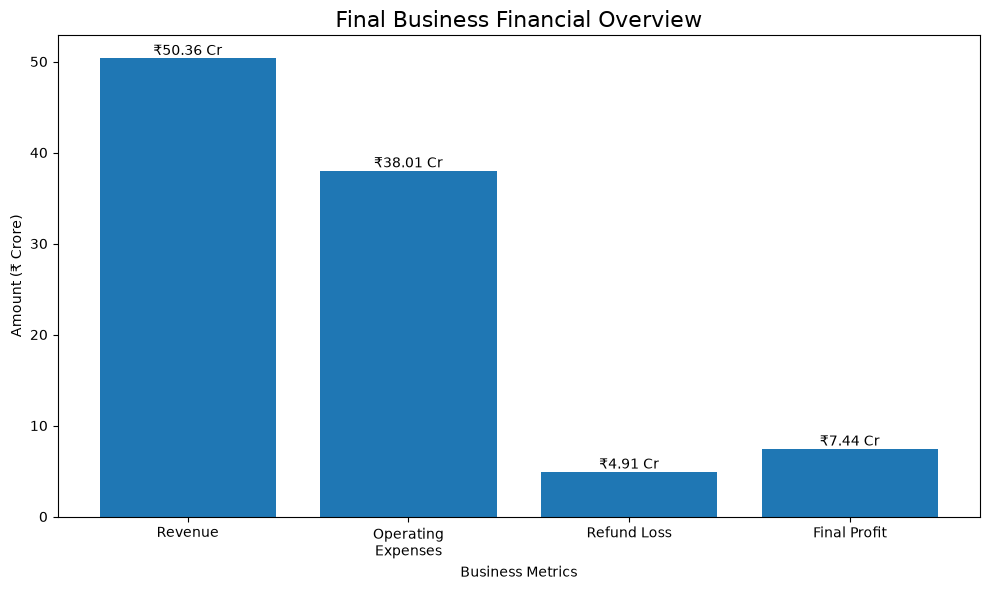

In [9]:
# FINAL BUSINESS KPI DASHBOARD

import matplotlib.pyplot as plt

metrics = [
    "Revenue",
    "Operating\nExpenses",
    "Refund Loss",
    "Final Profit"
]

values = [
    total_revenue / 1e7,
    total_expenses / 1e7,
    total_refund_loss / 1e7,
    final_profit_loss / 1e7
]

plt.figure(figsize=(10, 6))

bars = plt.bar(metrics, values)

plt.title("Final Business Financial Overview", fontsize=16)
plt.ylabel("Amount (₹ Crore)")
plt.xlabel("Business Metrics")

# Add values on bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value:.2f} Cr",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

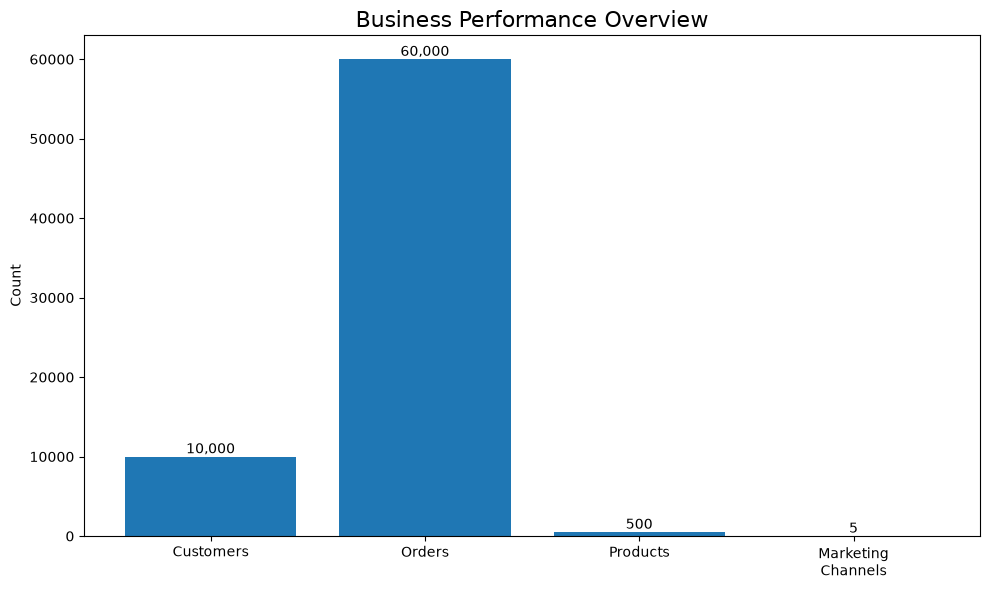

In [10]:
# FINAL BUSINESS PERFORMANCE OVERVIEW

categories = [
    "Customers",
    "Orders",
    "Products",
    "Marketing\nChannels"
]

values = [
    total_customers,
    total_orders,
    products["product_id"].nunique(),
    marketing["channel"].nunique()
]

plt.figure(figsize=(10, 6))

bars = plt.bar(categories, values)

plt.title("Business Performance Overview", fontsize=16)
plt.ylabel("Count")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

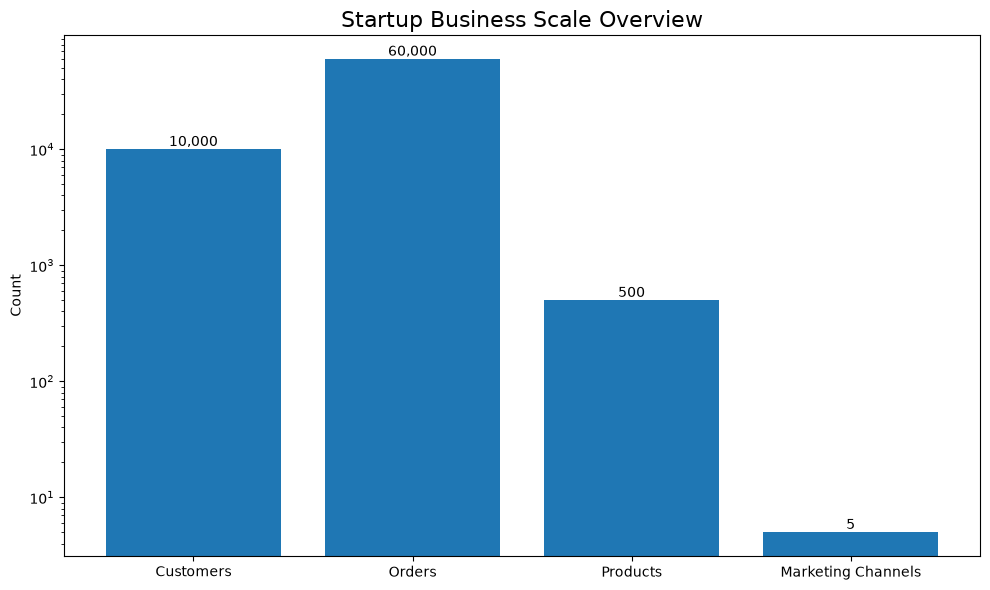

In [11]:
# BUSINESS SCALE OVERVIEW

metrics = [
    "Customers",
    "Orders",
    "Products",
    "Marketing Channels"
]

values = [
    total_customers,
    total_orders,
    products["product_id"].nunique(),
    marketing["channel"].nunique()
]

plt.figure(figsize=(10, 6))

bars = plt.bar(metrics, values)

plt.title("Startup Business Scale Overview", fontsize=16)
plt.ylabel("Count")

plt.yscale("log")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Executive Summary

The Startup Growth & Revenue Intelligence Platform analyzed customer behavior, sales performance, product profitability, marketing efficiency, operating expenses, returns, and future revenue trends.

## Key Business Results

- Total Revenue: ₹50.36 Crore
- Total Orders: 60,000
- Total Customers: 10,000
- Total Products: 500
- Total Operating Expenses: ₹38.01 Crore
- Total Refund Loss: ₹4.91 Crore
- Final Profit: ₹7.44 Crore
- Final Profit Margin: 14.77%

## Key Findings

1. The business generated strong revenue of ₹50.36 Crore.
2. Operating expenses and refund losses significantly affected profitability.
3. Google Ads was identified as the best-performing marketing channel.
4. YouTube had the lowest marketing performance score and requires optimization.
5. Several products were identified as Star Products with high revenue and high profitability.
6. Some products generated high revenue but low profit margins, indicating a need for pricing or cost optimization.
7. Customer analysis identified valuable customers who are At Risk and should be targeted with retention campaigns.
8. The 6-month revenue forecast predicts relatively stable monthly revenue of approximately ₹2.63 Crore.

## Final Recommendations

- Reduce unnecessary operating and infrastructure expenses.
- Improve delivery and product quality to reduce refund losses.
- Invest more strategically in high-performing marketing channels.
- Optimize or reduce spending on low-performing marketing channels.
- Promote Star Products and improve margins for low-profit products.
- Create personalized retention campaigns for high-value At-Risk customers.
- Use revenue forecasting for future inventory, budgeting, and growth planning.

## Conclusion

This project demonstrates how data analytics can help a startup transform raw business data into actionable insights. By combining sales, customer, product, marketing, expense, return, and forecasting analysis, the platform provides a complete view of business performance and supports data-driven strategic decision-making.

# 🎯 Strategic Business Recommendations

Based on the analysis of Sales, Products, Marketing, Returns, Expenses, and Revenue Forecasting, the following strategic recommendations are identified.

In [12]:
print("STRATEGIC BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1. Increase investment in Google Ads
   - Google Ads has the highest marketing performance score.
   - Allocate more budget to high-performing campaigns.

2. Optimize YouTube Marketing
   - YouTube has the lowest performance score.
   - Review campaign targeting and conversion strategy.

3. Focus on Star Products
   - Promote high-revenue and high-profit products.
   - Ensure sufficient inventory for these products.

4. Improve Underperforming Products
   - Review pricing, discounts, and customer demand.
   - Consider improving or discontinuing consistently poor products.

5. Reduce High Revenue but Low Profit Products
   - Analyze high costs and excessive discounts.
   - Improve profit margins through pricing optimization.

6. Control Operating Expenses
   - Operating expenses are a major cost component.
   - Identify departments with unnecessary spending.

7. Reduce Refund Loss
   - Analyze return reasons.
   - Improve product quality and customer expectations.

8. Revenue Forecast Action
   - Expected monthly revenue is approximately ₹2.63 Crore.
   - Use the forecast for inventory, marketing, and budget planning.
""")

STRATEGIC BUSINESS RECOMMENDATIONS

1. Increase investment in Google Ads
   - Google Ads has the highest marketing performance score.
   - Allocate more budget to high-performing campaigns.

2. Optimize YouTube Marketing
   - YouTube has the lowest performance score.
   - Review campaign targeting and conversion strategy.

3. Focus on Star Products
   - Promote high-revenue and high-profit products.
   - Ensure sufficient inventory for these products.

4. Improve Underperforming Products
   - Review pricing, discounts, and customer demand.
   - Consider improving or discontinuing consistently poor products.

5. Reduce High Revenue but Low Profit Products
   - Analyze high costs and excessive discounts.
   - Improve profit margins through pricing optimization.

6. Control Operating Expenses
   - Operating expenses are a major cost component.
   - Identify departments with unnecessary spending.

7. Reduce Refund Loss
   - Analyze return reasons.
   - Improve product quality and customer 

In [13]:
print("FINAL BUSINESS CONCLUSION")
print("=" * 60)

print(f"""
The business generated total revenue of ₹50.36 Crore.

After accounting for:
- Operating Expenses: ₹38.01 Crore
- Refund Loss: ₹4.91 Crore

The final business profit is ₹7.44 Crore,
with a profit margin of 14.77%.

Key Focus Areas:
✓ Increase investment in high-performing marketing channels.
✓ Focus on profitable Star Products.
✓ Improve underperforming products.
✓ Reduce refund losses.
✓ Control operating expenses.
✓ Optimize high-revenue but low-profit products.
✓ Use revenue forecasting for future planning.
""")

FINAL BUSINESS CONCLUSION

The business generated total revenue of ₹50.36 Crore.

After accounting for:
- Operating Expenses: ₹38.01 Crore
- Refund Loss: ₹4.91 Crore

The final business profit is ₹7.44 Crore,
with a profit margin of 14.77%.

Key Focus Areas:
✓ Increase investment in high-performing marketing channels.
✓ Focus on profitable Star Products.
✓ Improve underperforming products.
✓ Reduce refund losses.
✓ Control operating expenses.
✓ Optimize high-revenue but low-profit products.
✓ Use revenue forecasting for future planning.



In [14]:
print("STRATEGIC BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1. Increase investment in high-performing marketing channels,
   especially Google Ads and Referral campaigns.

2. Improve or optimize underperforming products to reduce
   low-profit inventory.

3. Focus on Growth Opportunity products through targeted
   marketing and promotional campaigns.

4. Analyze High Revenue but Low Profit products and reduce
   costs or optimize pricing.

5. Reduce refund losses by analyzing return reasons and
   improving product quality.

6. Control operating expenses to improve the overall
   profit margin.

7. Use revenue forecasting insights for inventory and
   financial planning.

8. Focus on high-margin product categories to improve
   long-term profitability.
""")

STRATEGIC BUSINESS RECOMMENDATIONS

1. Increase investment in high-performing marketing channels,
   especially Google Ads and Referral campaigns.

2. Improve or optimize underperforming products to reduce
   low-profit inventory.

3. Focus on Growth Opportunity products through targeted
   marketing and promotional campaigns.

4. Analyze High Revenue but Low Profit products and reduce
   costs or optimize pricing.

5. Reduce refund losses by analyzing return reasons and
   improving product quality.

6. Control operating expenses to improve the overall
   profit margin.

7. Use revenue forecasting insights for inventory and
   financial planning.

8. Focus on high-margin product categories to improve
   long-term profitability.



# Final Executive Summary

This project analyzed Sales, Customers, Products, Marketing, Expenses, Returns, and Revenue Forecasting data to understand overall business performance.

The analysis identified key revenue drivers, profitable products, high-performing marketing channels, underperforming areas, refund losses, operating expenses, and future revenue trends.

## Key Findings

- Total Revenue: ₹50.36 Crore
- Total Orders: 60,000
- Total Customers: 10,000
- Total Operating Expenses: ₹38.01 Crore
- Total Refund Loss: ₹4.91 Crore
- Final Profit: ₹7.44 Crore
- Overall Profit Margin: 14.77%

The analysis shows that while the business generates strong revenue, operating expenses and refund losses significantly impact profitability.

Product analysis identified Star Products, Underperforming Products, High Revenue Low Profit Products, and Growth Opportunities.

Google Ads was identified as the best-performing marketing channel, while YouTube showed the lowest overall performance score.

The 6-month revenue forecast predicts relatively stable monthly revenue of approximately ₹2.63 Crore.

## Final Conclusion

The business should focus on improving profitability rather than only increasing revenue. Strategic actions such as optimizing underperforming products, reducing refund losses, controlling expenses, improving low-profit products, and investing in high-performing marketing channels can help improve long-term business growth and profitability.